<a href="https://colab.research.google.com/github/robotlover2/deeplearning26.08.10/blob/main/08.12%2012_CNN_%EC%9D%B4%EC%A7%84%EB%B6%84%EB%A5%98_%ED%8F%90%EB%A0%B4%EB%B6%84%EB%A5%98_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN 이진분류 프로젝트: 흉부 X-Ray 폐렴 분류 (학생용 실습본)

## 학습 목표

1. `NORMAL`과 `PNEUMONIA` 흉부 X-Ray 이미지를 불러온다.
2. 학습·검증·테스트 데이터의 역할을 구분한다.
3. 이미지를 그레이스케일로 변환하고 정규화한다.
4. CNN 이진분류 모델을 구성하고 학습한다.
5. 정확도, 손실, 정밀도, 재현율을 확인한다.
6. 혼동행렬과 분류 보고서로 오류 유형을 분석한다.
7. 학습한 모델을 `.keras` 형식으로 저장한다.

> 본 예제는 교육용 이미지 분류 실습이다. 실제 의료 진단에 사용할 수 없다.

## 이 노트북 사용법 — 학생용 실습본

이 파일은 **핵심 코드가 빈칸(`____`)으로 비워진 실습본**이다.
수업 중 강사의 설명을 들으며 빈칸을 직접 채워 넣는다.

### 진행 방법

1. 코드 셀 위쪽의 **`채울 곳`** 안내 블록을 먼저 읽는다.
2. 코드 안의 `____` 를 찾아 알맞은 값·함수 이름으로 바꾼다. 각 빈칸에는 `①` `②` 번호가 붙어 있다.
3. `Shift + Enter` 로 셀을 실행한다.

### 실행하면 이런 오류가 난다면

| 오류 메시지 | 원인 |
|---|---|
| `NameError: name '____' is not defined` | 아직 채우지 않은 빈칸이 남아 있다 |
| `SyntaxError` | 빈칸을 지우면서 괄호·따옴표를 함께 지웠다 |

> 빈칸이 아닌 부분은 이미 완성되어 있으니 고치지 않아도 된다.
> 막히면 손을 들거나 채팅으로 알리자. 정답본은 수업 후 배포된다.

## 1.라이브러리 불러오기

In [1]:
import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#callback 함수


# 실행 결과 재현을 위한 시드 설정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2.데이터셋 내려받기

데이터셋 폴더는 다음 구조를 사용한다.

```text
chest_xray/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
```

In [2]:
# Colab에서 데이터셋을 내려받을 때 실행한다.
# 이미 chest_xray 폴더가 있다면 이 셀은 생략할 수 있다.

if not os.path.exists("./chest_xray"):
    !gdown 1MQU41YrOLGjvpXxKgda2v1AL2CXLEiys
    !unzip -qq "chest_xray.zip"

print("데이터셋 폴더 존재 여부:", os.path.exists("./chest_xray"))

Downloading...
From (original): https://drive.google.com/uc?id=1MQU41YrOLGjvpXxKgda2v1AL2CXLEiys
From (redirected): https://drive.google.com/uc?id=1MQU41YrOLGjvpXxKgda2v1AL2CXLEiys&confirm=t&uuid=8f83cb0e-72e9-47f4-bde5-4077ef396a5b
To: /content/chest_xray.zip
100% 1.23G/1.23G [00:17<00:00, 68.6MB/s]
데이터셋 폴더 존재 여부: True


## 3.이미지 전처리 함수 정의

흉부 X-Ray는 회색조 영상이므로 1채널 그레이스케일로 읽는다.

- 이미지 크기: `48 × 48`
- 픽셀값 범위: `0~255`에서 `0~1`
- 클래스 번호: `NORMAL=0`, `PNEUMONIA=1`

이미지를 train과 test label database로 만드는 과정


In [3]:
IMG_SIZE = 48
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
CLASS_TO_INDEX = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

def load_image_data(folder_path, img_size=IMG_SIZE):
    """지정한 폴더에서 흉부 X-Ray 이미지와 레이블을 불러온다."""

    # 이미지를 읽어서 numpy로 변환해줌

    images = []
    labels = []

    for class_name in CLASS_NAMES: #chest.xray 폴더에서 normal과 PNEUmonia를 골라서
        class_folder = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_folder):
            raise FileNotFoundError(f"클래스 폴더를 찾을 수 없다: {class_folder}")

        for file_name in sorted(os.listdir(class_folder)): # normal/페렴의 하위 폴더를 다 가져와서 하나씩
            file_path = os.path.join(class_folder, file_name)# 읽어온다

            # 흉부 X-Ray를 1채널 그레이스케일로 읽는다.
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                print(f"읽을 수 없는 파일: {file_path}")
                continue

            image = cv2.resize(image, (img_size, img_size))
            image = image.astype("float32") / 255.0

            #size와 정규화 해서

            # CNN 입력 형태를 (높이, 너비, 채널)로 3차원으로  맞춘다.
            image = np.expand_dims(image, axis=-1)

            images.append(image)
            labels.append(CLASS_TO_INDEX[class_name])

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

## 4.학습·검증·테스트 데이터 구성

원본 `test` 데이터는 최종 평가에만 사용한다.  
검증 데이터는 원본 `train` 폴더에서 층화 분할하여 만든다.

이렇게 하면 테스트 데이터가 학습 과정에 섞이는 데이터 누수를 방지할 수 있다.

In [4]:
# ┌─ 채울 곳 ─────────────────────────────
# ① 학습 데이터 중 검증용으로 뗄 비율 : 0.2
# ② 클래스 비율을 유지하며 나누려면 무엇을 기준으로? (라벨 배열)
# └──────────────────────────────────

DATA_ROOT = "./chest_xray"

# 원본 train 폴더에서 학습용 전체 데이터를 불러온다.
X_all_train, y_all_train = load_image_data( # ①
    os.path.join(DATA_ROOT, "train")
)

# 원본 test 폴더는 최종 평가용으로만 사용한다.
X_test, y_test = load_image_data(  # ①
    os.path.join(DATA_ROOT, "test")
)

# 클래스 비율을 유지하면서 학습·검증 데이터로 분할한다.
X_train, X_val, y_train, y_val = train_test_split(
    X_all_train,
    y_all_train,
    test_size=0.2,          # ②
    random_state=SEED,
    stratify=y_all_train            # ③
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (4168, 48, 48, 1)
y_train: (4168,)
X_val  : (1042, 48, 48, 1)
y_val  : (1042,)
X_test : (624, 48, 48, 1)
y_test : (624,)


## 5.클래스 분포 확인

In [5]:
def show_class_distribution(labels, dataset_name):
    unique, counts = np.unique(labels, return_counts=True)

    distribution = {
        CLASS_NAMES[class_index]: count
        for class_index, count in zip(unique, counts)
    }

    print(f"{dataset_name} 클래스 분포:", distribution)

show_class_distribution(y_train, "학습")
show_class_distribution(y_val, "검증")
show_class_distribution(y_test, "테스트")

학습 클래스 분포: {'NORMAL': np.int64(1073), 'PNEUMONIA': np.int64(3095)}
검증 클래스 분포: {'NORMAL': np.int64(268), 'PNEUMONIA': np.int64(774)}
테스트 클래스 분포: {'NORMAL': np.int64(234), 'PNEUMONIA': np.int64(390)}


## 6.이미지 시각화

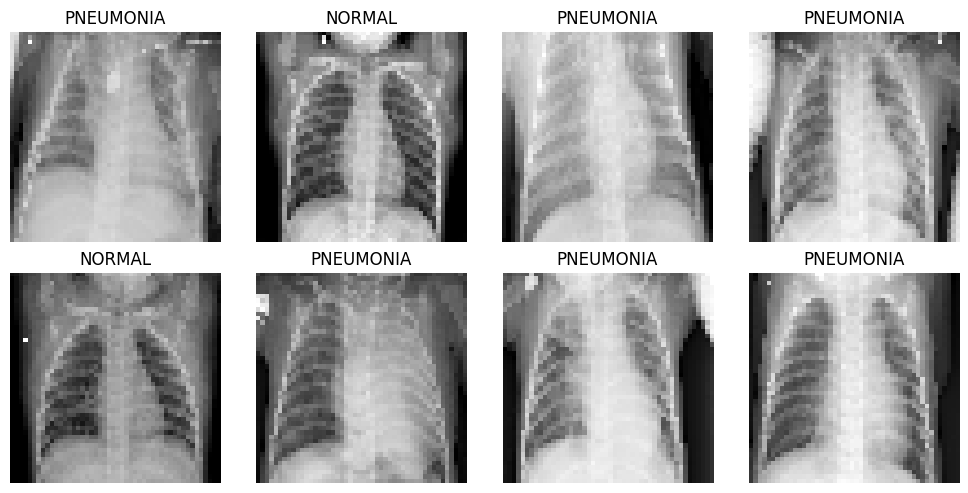

In [6]:
plt.figure(figsize=(10, 5))

sample_indices = np.random.choice(
    len(X_train),
    size=8,
    replace=False
)

for plot_index, image_index in enumerate(sample_indices):
    plt.subplot(2, 4, plot_index + 1)
    plt.imshow(X_train[image_index].squeeze(), cmap="gray")
    plt.title(CLASS_NAMES[y_train[image_index]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7.데이터 증강 정의

데이터 증강은 학습 중에만 적용된다.  
흉부 X-Ray의 좌우 방향에는 의미가 있을 수 있으므로 수평 반전은 적용하지 않는다.

In [8]:
#CNN의 openCV 증강 Radom Rotaion, translation zoom 등을 알아서 해줌
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor=0.03,
        fill_mode="nearest"
    ),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="nearest"
    ),
    tf.keras.layers.RandomZoom(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="nearest"
    )
], name="data_augmentation")

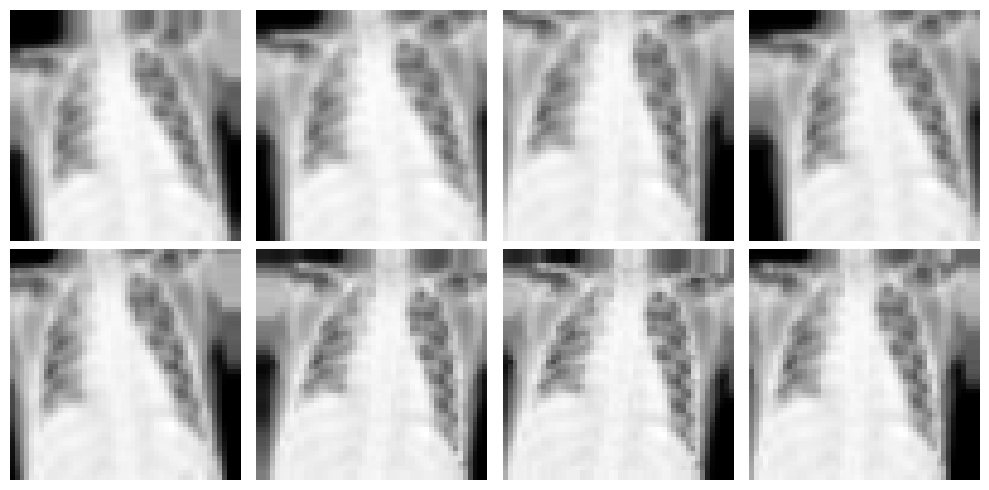

In [9]:
# 동일한 원본 이미지 한 장에 무작위 증강을 8번 적용해 확인한다.
sample_image = X_train[:1]

plt.figure(figsize=(10, 5))

for i in range(8):
    augmented_image = data_augmentation(
        sample_image,
        training=True
    )[0]

    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented_image[..., 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8.CNN 모델 구성

이진분류 모델이므로 출력층은 `Dense(1, activation='sigmoid')`를 사용한다.

In [10]:
# ┌─ 채울 곳 ─────────────────────────────
# ① 첫 블록의 필터 개수 : 16 (블록마다 32, 64로 두 배씩 늘린다)
# ② 은닉층 활성화 함수 (문자열)
# ③ 출력층 : 이진 분류이므로 뉴런 수와 활성화 함수는?
# └──────────────────────────────────

model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 1)), # 지금은 연습이라서 48 실제로면 조금 더 커야 함 한 200


    data_augmentation,#증강

    Conv2D(16, kernel_size=3, padding="same", activation='relu'),   # ① ②
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    #걍 공식처럼 이런걸 외우면 됌




    Conv2D(32, kernel_size=3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),

    GlobalAveragePooling2D(), # 1차원으로 바꿔주는 함수 flatten은 배열로 만드는 거고
    #4개의 평균을 내서 추출해서 사용한다


    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')    # ③
])

# 모델의 레이어 구성과 파라미터 수를 확인한다.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,225 (110.25 KB)

 Trainable params: 27,873 (108.88 KB)

 Non-trainable params: 352 (1.38 KB)

## 9.모델 컴파일

폐렴은 클래스 번호 `1`이므로 `Precision`과 `Recall`은 폐렴 클래스를 기준으로 계산된다.

In [12]:
# ┌─ 채울 곳 ──────────────────────────────
# ① 손실 함수 : 정답이 0/1 두 가지인 이진 분류용 crossentropy (문자열)
# └───────────────────────────────────

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='binary_crossentropy',   # ① 이진 분류라서 binary 사용하고 또한 페렴 환자니깐 Recall 도 꼭 확인 해야함
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

## 10.클래스 가중치 계산

학습 데이터의 클래스 불균형을 완화하기 위해 클래스 가중치를 적용한다.

In [20]:
#페렴 환자가 압도적으로 많았으므로 가중치를 정해준다
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = {
    int(class_index): float(weight)
    for class_index, weight
    in zip(np.unique(y_train), class_weights_array)
}

print("클래스 가중치:", class_weight)

클래스 가중치: {0: 1.9422180801491147, 1: 0.6733441033925687}


## 11.모델 학습

In [21]:
# ┌─ 채울 곳 ────────────────────────
# ① 학습 중 성능을 점검할 데이터 : 검증셋 튜플
# └──────────────────────────────

EPOCHS = 30
BATCH_SIZE = 32

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),        # ① 아까 만든 검증 데이터
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    class_weight=class_weight
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9206 - loss: 0.1851 - precision: 0.9769 - recall: 0.9147 - val_accuracy: 0.8599 - val_loss: 0.3564 - val_precision: 0.9984 - val_recall: 0.8127 - learning_rate: 2.7000e-05
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9160 - loss: 0.1922 - precision: 0.9761 - recall: 0.9092 - val_accuracy: 0.8167 - val_loss: 0.4927 - val_precision: 0.9983 - val_recall: 0.7545 - learning_rate: 2.7000e-05
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9194 - loss: 0.1978 - precision: 0.9777 - recall: 0.9133
Epoch 3: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9203 - loss: 0.1960 - precision: 0.9769 - recall: 0.9144 - val_accuracy: 0.8378 - val_loss: 0.4207 - val_precision: 0.9984 - val_recall: 0.7829 - learning_rate: 2.7000e-05
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9167 - loss: 0.1905 - preci

## 12.모델 학습 과정 시각화

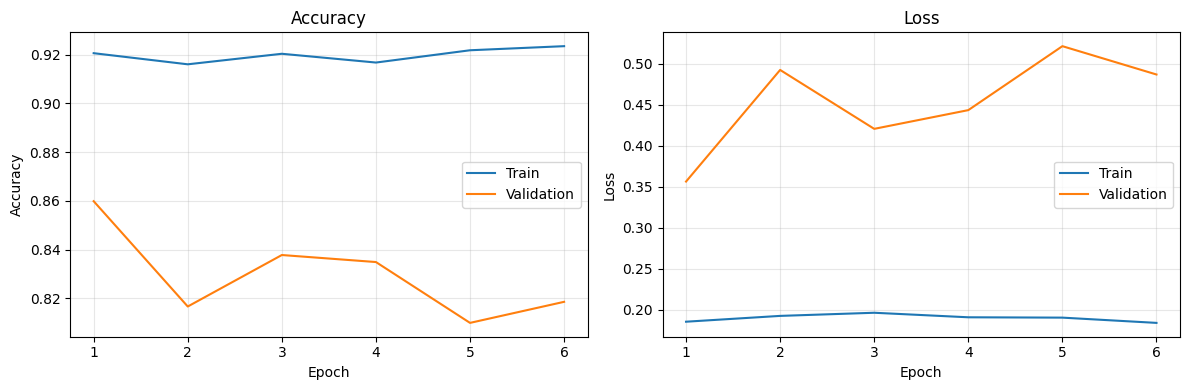

In [22]:
epoch_range = range(
    1,
    len(history.history["loss"]) + 1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 정확도
axes[0].plot(
    epoch_range,
    history.history["accuracy"],
    label="Train"
)
axes[0].plot(
    epoch_range,
    history.history["val_accuracy"],
    label="Validation"
)
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 손실
axes[1].plot(
    epoch_range,
    history.history["loss"],
    label="Train"
)
axes[1].plot(
    epoch_range,
    history.history["val_loss"],
    label="Validation"
)
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13.모델 평가

In [23]:
test_result = model.evaluate(
    X_test,
    y_test,
    return_dict=True,
    verbose=1
)

print("\n테스트 평가 결과")

for metric_name, metric_value in test_result.items():
    print(f"{metric_name}: {metric_value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8542 - loss: 0.3509 - precision: 0.8843 - recall: 0.8821

테스트 평가 결과
accuracy: 0.8542
loss: 0.3509
precision: 0.8843
recall: 0.8821


## 14.모델 예측

In [24]:
# ┌─ 채울 곳 ───────────────────────────────
# ① 판정 임계값 : 확률이 이 값 이상이면 PNEUMONIA(1)로 본다 — 기본 0.5
# └─────────────────────────────────────

# sigmoid 출력값은 PNEUMONIA 클래스일 확률로 해석한다.
prediction_probabilities = model.predict(
    X_test,
    verbose=0
).reshape(-1)

predictions = (
    prediction_probabilities >= 0.5     # ①
).astype(np.int32)

df_result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions,
    "Pneumonia_Probability": prediction_probabilities
})

df_result.head()

,Actual,Predicted,Pneumonia_Probability
0,0,0,0.052300
1,0,0,0.029994
2,0,0,0.007861
3,0,0,0.009777
4,0,0,0.002486


## 15.혼동행렬

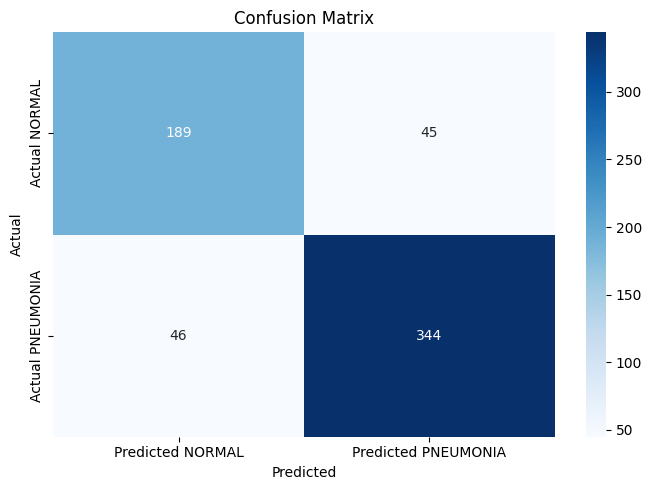

In [25]:
cm = confusion_matrix(
    y_test,
    predictions
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual NORMAL",
        "Actual PNEUMONIA"
    ],
    columns=[
        "Predicted NORMAL",
        "Predicted PNEUMONIA"
    ]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 16.분류 보고서

In [26]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)

              precision    recall  f1-score   support

      NORMAL     0.8043    0.8077    0.8060       234
   PNEUMONIA     0.8843    0.8821    0.8832       390

    accuracy                         0.8542       624
   macro avg     0.8443    0.8449    0.8446       624
weighted avg     0.8543    0.8542    0.8542       624



## 17.이미지별 예측 결과 확인

/tmp/ipykernel_4532/2843714369.py:29: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2843714369.py:29: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2843714369.py:29: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2843714369.py:29: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2843714369.py:29: UserWarning: Glyph 54224 (\N{HANGUL SYLLABLE PYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2843714369.py:29: UserWarning: Glyph 47156 (\N{HANGUL SYLLABLE RYEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2843714369.py:29: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.ti

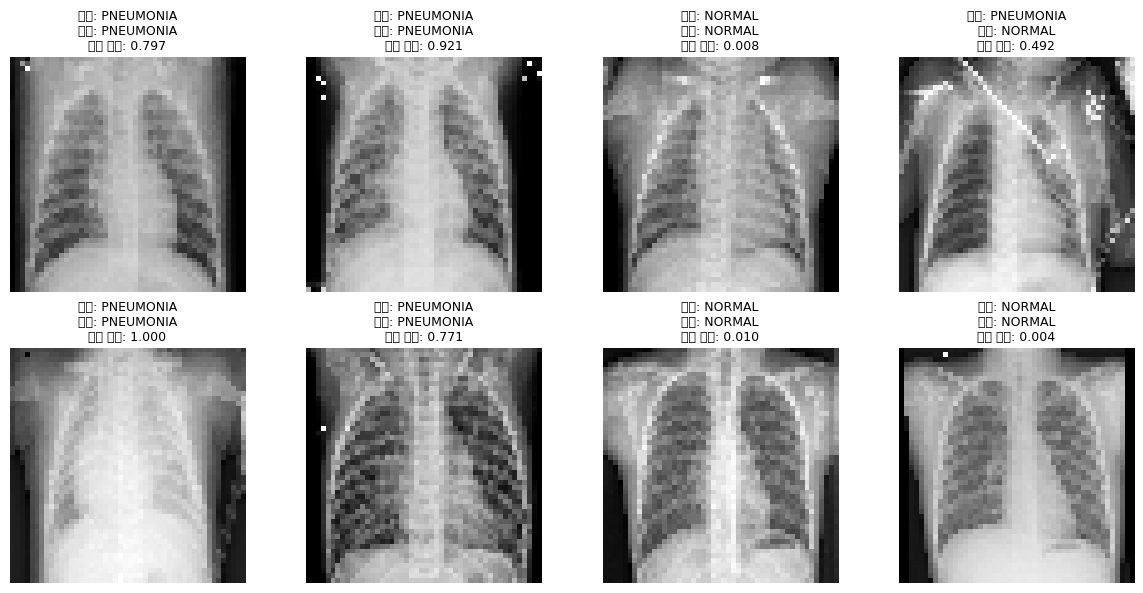

In [27]:
NUM_IMAGES = 8

samples_to_display = np.random.choice(
    len(X_test),
    size=NUM_IMAGES,
    replace=False
)

plt.figure(figsize=(12, 6))

for plot_index, image_index in enumerate(samples_to_display):
    true_label = y_test[image_index]
    predicted_label = predictions[image_index]
    probability = prediction_probabilities[image_index]

    plt.subplot(2, 4, plot_index + 1)
    plt.imshow(
        X_test[image_index].squeeze(),
        cmap="gray"
    )
    plt.title(
        f"정답: {CLASS_NAMES[true_label]}\n"
        f"예측: {CLASS_NAMES[predicted_label]}\n"
        f"폐렴 확률: {probability:.3f}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 18.오분류 이미지 확인

오분류 수: 91 / 624


/tmp/ipykernel_4532/2688160110.py:32: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2688160110.py:32: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2688160110.py:32: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2688160110.py:32: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2688160110.py:32: UserWarning: Glyph 54224 (\N{HANGUL SYLLABLE PYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2688160110.py:32: UserWarning: Glyph 47156 (\N{HANGUL SYLLABLE RYEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/2688160110.py:32: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.ti

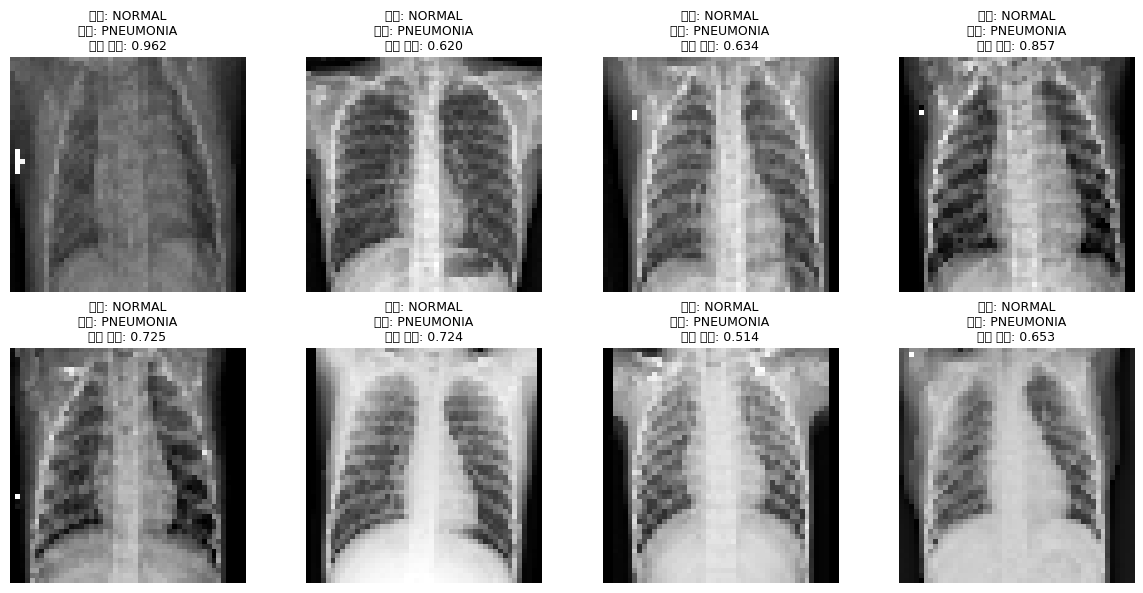

In [28]:
wrong_indices = np.where(
    predictions != y_test
)[0]

print(
    f"오분류 수: {len(wrong_indices)} / {len(y_test)}"
)

num_wrong_to_show = min(8, len(wrong_indices))

if num_wrong_to_show == 0:
    print("오분류 이미지가 없다.")
else:
    plt.figure(figsize=(12, 6))

    for plot_index, image_index in enumerate(
        wrong_indices[:num_wrong_to_show]
    ):
        plt.subplot(2, 4, plot_index + 1)
        plt.imshow(
            X_test[image_index].squeeze(),
            cmap="gray"
        )
        plt.title(
            f"정답: {CLASS_NAMES[y_test[image_index]]}\n"
            f"예측: {CLASS_NAMES[predictions[image_index]]}\n"
            f"폐렴 확률: {prediction_probabilities[image_index]:.3f}",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 19.모델 저장 및 다시 불러오기

`.keras` 파일에는 모델 구조와 가중치가 함께 저장된다.

In [29]:
MODEL_PATH = "x_ray_cnn_binary.keras"

model.save(MODEL_PATH)

print(f"모델 저장 완료: {MODEL_PATH}")

loaded_model = tf.keras.models.load_model(
    MODEL_PATH
)

loaded_result = loaded_model.evaluate(
    X_test,
    y_test,
    return_dict=True,
    verbose=0
)

print("불러온 모델의 테스트 정확도:", loaded_result["accuracy"])

모델 저장 완료: x_ray_cnn_binary.keras
불러온 모델의 테스트 정확도: 0.8541666865348816
